In [5]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import polars as pl
from pprint import pprint
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from scipy.ndimage import gaussian_filter

In [6]:
match_df = pl.read_parquet('Skillcorner data/RealMadrid/matches.parquet')
# Data is only available for "closed" matches
match_df = match_df.filter(pl.col('status') == 'closed')
match_ids = match_df['id'].to_list()
# match_ids = match_df.filter(pl.col('competition_edition_id').is_in([900, 546]))['id'].to_list()
print('Num of matches:', len(match_ids))

Num of matches: 98


In [95]:
REAL_MADRID_TEAM_ID = 262

# Derived data storage
data = {
  'match_id': [],
  'rma_shots': [],
  'rma_goals': [],
  'def_median': [],
  'mid_median': [],
  'att_median': [],
  'def_compact': [],
  'mid_compact': [],
  'att_compact': [],
  'horiz_compact': [],
  'vert_compact': [],
  'num_pressures': [],
  'home_team': [],
  'away_team': [],
  'rma_opponent': [],
  'num_shots_behind_def_line': [],
  'num_goals_behind_def_line': [],
  'min_horiz_avg': [],
  'num_shots_behind_horiz': [],
}

heatmap_matches = [1534700, 1816744, 1103734, 2007191]
heatmap_data = {k: {} for k in heatmap_matches}

for match_id in match_ids:
  # Load meta data for match
  meta_df = pl.read_json(f'Skillcorner data/RealMadrid/meta/{match_id}.json')
  meta_players_df = meta_df.select('players').explode('players').unnest('players')
  meta_players_df = (
    meta_players_df.with_columns(
      pl.col('player_role').name.prefix_fields('player_role_')
    ).unnest('player_role')
  ).rename({'id': 'player_id', 'short_name': 'player_short_name'})
  rma_non_gk_player_ids = meta_players_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('player_role_acronym') != 'GK')['player_id'].to_list()
  oppo_non_gk_player_ids = meta_players_df.filter(
    pl.col('team_id') != REAL_MADRID_TEAM_ID,
    pl.col('player_role_acronym') != 'GK')['player_id'].to_list()

  # Transform data so that Real Madrid is alway left to right
  # First determine which half to transform coordinates
  is_rma_home = (meta_df['home_team'].struct.field('id') == REAL_MADRID_TEAM_ID).item()
  home_l2r_half = meta_df['home_team_side'].item().to_list().index('right_to_left') + 1
  if is_rma_home:
    period_to_swap = home_l2r_half
  else:
    period_to_swap = 3 - home_l2r_half

  home_team = meta_df['home_team'].struct.field('short_name').item()
  away_team = meta_df['away_team'].struct.field('short_name').item()
  if is_rma_home:
    rma_opponent = away_team
  else:
    rma_opponent = home_team

  # Load tracking data for match
  track_df = pl.read_json(f'Skillcorner data/RealMadrid/tracking/{match_id}.json', infer_schema_length=10_000)
  # Only get rows that have valid timestamps and players
  track_frames_df = track_df.filter(pl.col('timestamp').is_not_null(), pl.col('player_data').list.len() != 0)
  ball_coords_df = track_frames_df.select(
    pl.col('frame'),
    pl.col('period'),
    pl.col('ball_data').struct.field('x'),
    pl.col('ball_data').struct.field('y'),
  )
  track_players_df = (                                                                                                               
      track_frames_df.select(['frame', 'timestamp', 'period', 'player_data'])                                                                         
      .explode('player_data')                                                                                                        
      .unnest('player_data')
  )
  # SkillCorner coordinate origin is located at the pitch center point
  # so to transform left-to-right and vice versa, multiply the coordinates
  # by -1. Here all RMA coordinates are transformed to left-to-right and
  # all opponent coordinates are transformed to right-to-left.
  track_players_df = track_players_df.with_columns(
    pl.when(pl.col('period') == period_to_swap)
    .then(pl.col('x', 'y') * -1)
    .otherwise(pl.col('x', 'y'))
  )
  ball_coords_df = ball_coords_df.with_columns(
    pl.when(pl.col('period') == period_to_swap)
    .then(pl.col('x') * -1)
    .otherwise(pl.col('x'))
  )
  # With all coordinates transformed for left to right for Real Madrid,
  # we can filter frames when the ball is in each third of the pitch.
  # +--------------------------------+--------------------------------+
  # |                     !          |          !                     |
  # |----+                !          |          !                +----|
  # |    |                !          |          !                |    |
  # |  RMA defensive 3rd  !     RMA mid 3rd     !  RMA attacking 3rd  |
  # |   -52.5 to -17.5    !    -17.5 to 17.5    !    17.5 to 52.5     |
  # |         35m         !         35m         !         35m         |
  # |    |                !          |          !                |    |
  # |----+                !          |          !                +----|
  # |                     !          |          !                     |
  # +--------------------------------+--------------------------------+
  def_third_frames = ball_coords_df.filter(pl.col('x') < -17.5)['frame'].to_list()
  mid_third_frames = ball_coords_df.filter(pl.col('x').is_between(-17.5, 17.5))['frame'].to_list()
  att_third_frames = ball_coords_df.filter(pl.col('x') > 17.5)['frame'].to_list()

  # Load dynamic events for match
  try:
    dynam_df = pl.read_parquet(f'Skillcorner data/RealMadrid/dynamic/{match_id}.parquet')
  except FileNotFoundError:
    print(f'Missing dynamic data for match id {match_id}!')
    continue
  rma_shots_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('end_type') == 'shot',
  )
  num_rma_shots = rma_shots_df.shape[0]
  rma_goals_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('game_interruption_after') == 'goal_for'
  )
  num_rma_goals = rma_goals_df.shape[0]

  # Tracking data for each team
  rma_track_df = track_players_df.filter(pl.col('player_id').is_in(rma_non_gk_player_ids))
  oppo_track_df = track_players_df.filter(pl.col('player_id').is_in(oppo_non_gk_player_ids))

  # To get all the opponent's defensive frames we filter when the ball is in RMA's attacking 3rd
  oppo_def_frames_df = oppo_track_df.filter(pl.col('frame').is_in(att_third_frames))
  oppo_mid_frames_df = oppo_track_df.filter(pl.col('frame').is_in(mid_third_frames))
  # Likewise, for the opponent's attacking frames we filter when the ball is in RMA's defensive 3rd
  oppo_att_frames_df = oppo_track_df.filter(pl.col('frame').is_in(def_third_frames))

  # Here we get the median value of the opponent defender closest to the opponent's goal (highest x value) over the match
  def_median = oppo_def_frames_df.group_by('frame').agg(pl.col('x').top_k(3).mean())['x'].median()
  mid_median = oppo_mid_frames_df.group_by('frame').agg(pl.col('x').top_k(3).mean())['x'].median()
  # This gets the median of the highest meter the opponent's defense gets when attacking RMA
  att_median = oppo_att_frames_df.group_by('frame').agg(pl.col('x').top_k(3).mean())['x'].median()

  # Calculate the average compactness of the defense by getting the mean squared distance
  # from the centroid of all players
  avg_def_compactness = oppo_def_frames_df.with_columns(
    pl.col('x').mean().over('frame').alias('centroid_x'),
    pl.col('y').mean().over('frame').alias('centroid_y'),
  ).with_columns(
    (
      (pl.col('x') - pl.col('centroid_x')).pow(2) +
      (pl.col('y') - pl.col('centroid_y')).pow(2)
    ).sqrt().alias('dist_from_centroid'),
  ).group_by('frame').agg(
    pl.col('dist_from_centroid').mean().alias('compactness')
  )['compactness'].mean()

  oppo_compact_df = oppo_def_frames_df.select(
    pl.col('frame'),
    pl.col('x').top_k(8).max().over('frame').alias('max_horiz'),
    pl.col('x').top_k(8).min().over('frame').alias('min_horiz'),
  ).select(
    pl.col('max_horiz'),
    pl.col('min_horiz'),
    (pl.col('max_horiz') - pl.col('min_horiz')).alias('horiz_diff'),
  )
  avg_horiz_compactness = oppo_compact_df['horiz_diff'].mean()

  avg_vert_compactness = oppo_def_frames_df.select(
    pl.col('frame'),
    pl.col('y').top_k(8).max().over('frame').alias('max_vert'),
    pl.col('y').top_k(8).min().over('frame').alias('min_vert'),
  ).select(
    (pl.col('max_vert') - pl.col('min_vert')).alias('vert_diff'),
  )['vert_diff'].mean()

  pressures_on_rma = dynam_df.filter(
    pl.col('frame_start').is_in(att_third_frames) | pl.col('frame_end').is_in(att_third_frames)
  ).filter(
    pl.col('event_subtype') == 'pressure',
    pl.col('team_id') != REAL_MADRID_TEAM_ID,
  )
  num_pressures = pressures_on_rma.shape[0]

  shots_behind_def_line_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('end_type') == 'shot',
    pl.col('x_end') > def_median
  )
  num_shots_behind_def_line = shots_behind_def_line_df.shape[0]

  goals_behind_def_line_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('game_interruption_after') == 'goal_for',
    pl.col('x_end') > def_median,
  )
  num_goals_behind_def_line = goals_behind_def_line_df.shape[0]

  min_horiz_avg = oppo_compact_df['min_horiz'].mean()
  shots_behind_horiz_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('end_type') == 'shot',
    pl.col('x_end') > min_horiz_avg,
  )
  num_shots_behind_hoirz = shots_behind_horiz_df.shape[0]

  if match_id in heatmap_matches:
    oppo_def_coords_df = track_players_df.filter(
      pl.col('frame').is_in(att_third_frames),
      pl.col('player_id').is_in(oppo_non_gk_player_ids)
    )
    heatmap_data[match_id]['def_coords'] = oppo_def_coords_df
    heatmap_data[match_id]['line_height'] = def_median
    heatmap_data[match_id]['rma_shots'] = rma_shots_df.select(pl.col('x_end'), pl.col('y_end')).to_numpy()
    heatmap_data[match_id]['rma_goals'] = rma_goals_df.select(pl.col('x_end'), pl.col('y_end')).to_numpy()
    heatmap_data[match_id]['pressures'] = pressures_on_rma
    heatmap_data[match_id]['horiz_compact'] = oppo_compact_df.select(
      pl.col('max_horiz'), pl.col('min_horiz'), pl.col('horiz_diff')
    )
    heatmap_data[match_id]['home_team'] = home_team
    heatmap_data[match_id]['away_team'] = away_team
    heatmap_data[match_id]['home_team_score'] = meta_df['home_team_score'].item()
    heatmap_data[match_id]['away_team_score'] = meta_df['away_team_score'].item()
    heatmap_data[match_id]['date'] = datetime.strptime(meta_df['date_time'].item()[:10], '%Y-%m-%d').strftime('%B %d, %Y')

  # Populate data
  data['match_id'].append(match_id)
  data['rma_shots'].append(num_rma_shots)
  data['rma_goals'].append(num_rma_goals)
  data['def_median'].append(def_median)
  data['mid_median'].append(mid_median)
  data['att_median'].append(att_median)
  data['def_compact'].append(avg_def_compactness)
  data['horiz_compact'].append(avg_horiz_compactness)
  data['vert_compact'].append(avg_vert_compactness)
  data['num_pressures'].append(num_pressures)
  data['num_shots_behind_def_line'].append(num_shots_behind_def_line)
  data['num_goals_behind_def_line'].append(num_goals_behind_def_line)
  data['min_horiz_avg'].append(min_horiz_avg)
  data['num_shots_behind_horiz'].append(num_shots_behind_hoirz)
  data['home_team'].append(home_team)
  data['away_team'].append(away_team)
  data['rma_opponent'].append(rma_opponent)

print('Num data points:', len(data['match_id']))


Missing dynamic data for match id 1274919!
Num data points: 97


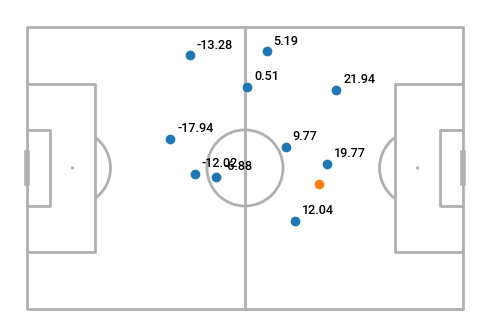

In [45]:
coords_df = oppo_def_frames_df.filter(pl.col('frame') == 123)
frame_pitch = Pitch(pitch_type='skillcorner', pitch_width=68, pitch_length=105)
fig, ax = frame_pitch.draw(figsize=(10/2, 7/2))
ax.scatter(coords_df['x'], coords_df['y'])
for x_val, y_val in zip(coords_df['x'].to_list(), coords_df['y'].to_list()):
  ax.annotate(f"{x_val:.2f}", (x_val, y_val), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)
ax.scatter(
  ball_coords_df.filter(pl.col('frame') == 123)['x'],
  ball_coords_df.filter(pl.col('frame') == 123)['y'],
)

In [9]:
# np.save('def_line_vs_shots.npy', np.array([data['def_median'], data['rma_shots']]))

In [78]:
rma_xg = pl.read_parquet('rma_xg.parquet')
oppo_xg = pl.read_parquet('oppo_xg.parquet')

actual_data = {k: v for k, v in data.items() if v}
data_df = pl.DataFrame(actual_data)

data_df = data_df.join(rma_xg, on='match_id', how='left').rename({'xG': 'rma_xG'})
data_df = data_df.join(oppo_xg, on='match_id', how='left').rename({'xG': 'oppo_xG'})
data_df

match_id,rma_shots,rma_goals,def_median,mid_median,att_median,def_compact,horiz_compact,vert_compact,num_pressures,home_team,away_team,rma_opponent,num_shots_behind_def_line,num_goals_behind_def_line,min_horiz_avg,num_shots_behind_horiz,rma_xG,oppo_xG
i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,str,str,str,i64,i64,f64,i64,f64,f64
2014987,15,3,37.146667,17.15,-1.07,15.757603,21.571542,30.999131,72,"""Real Madrid""","""Celta Vigo""","""Celta Vigo""",10,2,17.39302,15,2.031707,2.120334
2012892,14,1,33.206667,11.863333,-1.313333,14.261299,18.591135,28.486901,56,"""Getafe CF""","""Real Madrid""","""Getafe CF""",12,0,16.247417,14,1.30062,2.226184
2012431,19,1,36.513333,20.403333,0.876667,12.088855,15.969289,24.904605,132,"""Real Madrid""","""Athletic Bilbao""","""Athletic Bilbao""",12,1,21.340613,19,2.255361,0.312724
2011844,14,1,38.443333,15.713333,-1.95,11.670372,14.176995,24.769321,61,"""Real Madrid""","""Arsenal""","""Arsenal""",5,1,24.582495,13,1.218044,0.987843
2011428,9,1,34.193333,12.633333,-3.906667,13.304444,19.861753,27.255269,44,"""Alavés""","""Real Madrid""","""Alavés""",6,0,15.671935,9,0.790909,1.469547
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1096879,15,2,36.733333,12.766667,-1.386667,15.394642,21.840896,30.111448,65,"""Real Madrid""","""Real Sociedad""","""Real Sociedad""",10,1,15.55572,15,2.261996,1.874011
1064327,24,2,37.293333,17.726667,0.383333,11.652779,14.450743,22.109446,139,"""Real Madrid""","""Getafe CF""","""Getafe CF""",15,2,23.482008,24,2.695461,0.462158
1048195,9,1,37.17,18.843333,-1.596667,13.900901,18.641144,28.382072,89,"""Celta Vigo""","""Real Madrid""","""Celta Vigo""",5,1,19.933041,9,1.419457,1.23344


In [11]:
logo_lookup = {
  'Alavés': 'alaves',
 'Arsenal': 'arsenal',
 'Atalanta': 'atalanta',
 'Athletic Bilbao': 'athletic-club',
 'Atlético Madrid': 'atletico-madrid',
 'Bayern Munchen': 'bayern-münchen',
 'Betis Balompié': 'betis-balompie',
 'CA Osasuna': 'osasuna',
 'CF Cadiz': 'cadiz',
 'Celta Vigo': 'celta',
 'Dortmund': 'dortmund',
 'FC Barcelona': 'barcelona',
 'FC Union Berlin': 'union-berlin',
 'Getafe CF': 'getafe',
 'Girona': 'girona',
 'Granada CF': 'granada',
 'LOSC Lille': 'losc-lille',
 'Leganés': 'leganes',
 'Leipzig': 'leipzig',
 'Liverpool': 'liverpool',
 'Manchester City': 'manchester-city',
 'Milan': 'milan',
 'Napoli': 'napoli',
 'RCD Espanyol': 'espanyol',
 'RCD Mallorca': 'mallorca',
 'Rayo Vallecano': 'rayo-vallecano',
 'Real Sociedad': 'real-sociedad',
 'Real Valladolid': 'real-valladolid',
 'SC Braga': 'sc-braga',
 'Salzbourg': 'salzbourg',
 'Sevilla FC': 'sevilla',
 'Stade Brestois': 'stade-brestois',
 'Stuttgart': 'stuttgart',
 'UD Almería': 'almeria',
 'UD Las Palmas': 'las-palmas',
 'Valencia CF': 'valencia',
 'Villarreal CF': 'villarreal',
}

In [12]:
# Use a TTF font file for Matplotlib plot text
font_path = 'fonts/Roboto/static/Roboto-Medium.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()

# Plot colors
BG_COLOR = '#1e1e1e'
TEXT_COLOR = '#ffffff'
DOT_COLOR = 'lightgreen'
SLOPE_COLOR = '#00F5FF'
CI_COLOR = '#00E5FF'

In [90]:
def draw_plot(x, y, title, x_label, y_label, point_sizes=None, match_ids=None, show_grid=False, show_legend=True, opponents=None):
  fig, ax = plt.subplots(figsize=(10, 5))
  fig.set_facecolor(BG_COLOR)
  ax.set_facecolor(BG_COLOR)
  ax.set_xlabel(TEXT_COLOR)
  ax.set_ylabel(TEXT_COLOR)
  for spine in ax.spines.values():
    spine.set_color(TEXT_COLOR)
  ax.tick_params(axis='x', colors=TEXT_COLOR)
  ax.tick_params(axis='y', colors=TEXT_COLOR)

  sizes = point_sizes if point_sizes else 25
  plt.scatter(x, y, s=sizes, c=DOT_COLOR, label='Individual Match')

  # If opponent names are provided, add logos to the scatter plot points
  if opponents:
    for i, opponent in enumerate(opponents):
      fname = logo_lookup.get(opponent, None)
      if fname:
        try:
          logo = Image.open(f'logos/la-liga/{fname}.football-logos.cc.png').convert("RGBA")
        except:
          continue  # Skip if logo is not found or cannot be opened
        img_box = OffsetImage(logo, zoom=0.3)
        ab = AnnotationBbox(img_box, (x[i], y[i]), frameon=False, pad=0.0)
        ax.add_artist(ab)

  # Label points with match ids if provided
  if match_ids:
    for xi, yi, mid in zip(x, y, match_ids):
      plt.annotate(str(mid), (xi, yi), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, color=TEXT_COLOR)

  # Regression line
  coeffs = np.polyfit(x, y, 1)
  slope, intercept = coeffs
  x_line = np.linspace(x.min(), x.max(), 200)
  y_line = slope * x_line + intercept

  # Calculate standard error and confidence interval
  n = len(x)
  residuals = y - (slope * x + intercept)
  std_error = np.sqrt(np.sum(residuals**2) / (n - 2))
  x_mean = np.mean(x)
  sxx = np.sum((x - x_mean)**2)
  # 95% confidence interval
  t_val = stats.t.ppf(0.975, n - 2)
  margin = t_val * std_error * np.sqrt(1/n + (x_line - x_mean)**2 / sxx)
  uncertain_bound = t_val * (std_error / np.sqrt(sxx))

  plt.plot(x_line, y_line, color=SLOPE_COLOR, linestyle='--', linewidth=1, label=f'Slope: {slope:.2f} ± {uncertain_bound:.2f}')
  plt.fill_between(x_line, y_line - margin, y_line + margin, alpha=0.2, color=CI_COLOR)

  plt.title(title, color='white', size=18)
  plt.xlabel(x_label, color='white')
  plt.ylabel(y_label, color='white')
  if show_grid:
    plt.grid(True)
  if show_legend:
    plt.legend(
      facecolor=BG_COLOR,
      edgecolor=TEXT_COLOR,
      labelcolor=TEXT_COLOR,
    )
  plt.show()

In [86]:
def plot_line_height(x, y, title, x_label, y_label, point_colors=None, point_sizes=None, match_ids=None, opponents=None):
  fig, ax = plt.subplots(figsize=(10, 5))
  fig.set_facecolor(BG_COLOR)
  ax.set_facecolor(BG_COLOR)
  ax.set_xlabel(TEXT_COLOR)
  ax.set_ylabel(TEXT_COLOR)
  # ax.spines['bottom'].set_color(TEXT_COLOR)
  for spine in ax.spines.values():
    spine.set_color(TEXT_COLOR)
  ax.tick_params(axis='x', colors=TEXT_COLOR)
  ax.tick_params(axis='y', colors=TEXT_COLOR)

  # sizes = point_sizes if point_sizes else 25
  if point_sizes:
    plt.scatter(x, y, s=point_sizes, c=DOT_COLOR)
  else:
    plt.scatter(x, y, s=25, c=DOT_COLOR, label='Individual Match')

  goals_handles = None
  if point_sizes:
    uniq = sorted(set(point_sizes))
    leg_vals = []
    leg_lbls = []
    for i, s in enumerate(uniq):
      leg_vals.append(s)
      leg_lbls.append(f'{i} Goals')

    goals_handles = [
      Line2D([0], [0],
          marker='o',
          color='w',
          label=lbl,
          markerfacecolor=DOT_COLOR,
          markersize=np.sqrt(sz)+3,
          markeredgecolor='None',
          linestyle='None')
      for sz, lbl in zip(leg_vals, leg_lbls)
    ]

  # If opponent names are provided, add logos to the scatter plot points
  if opponents:
    for i, opponent in enumerate(opponents):
      fname = logo_lookup.get(opponent, None)
      if fname:
        try:
          logo = Image.open(f'logos/la-liga/{fname}.football-logos.cc.png').convert("RGBA")
        except:
          continue  # Skip if logo is not found or cannot be opened
        img_box = OffsetImage(logo, zoom=0.3)
        ab = AnnotationBbox(img_box, (x[i], y[i]), frameon=False, pad=0.0)
        ax.add_artist(ab)

  # Label points with match ids
  if match_ids:
    for xi, yi, mid in zip(x, y, match_ids):
      plt.annotate(str(mid), (xi, yi), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, color=TEXT_COLOR)

  # Regression line
  coeffs = np.polyfit(x, y, 1)
  slope, intercept = coeffs
  x_line = np.linspace(x.min(), x.max(), 200)
  y_line = slope * x_line + intercept

  # Calculate standard error and confidence interval
  n = len(x)
  residuals = y - (slope * x + intercept)
  # convert Polars Series to a numpy array to avoid numpy calling Series.sum(axis=...)
  # residuals = residuals.to_numpy()
  std_error = np.sqrt(np.sum(residuals**2) / (n - 2))
  x_mean = np.mean(x)
  sxx = np.sum((x - x_mean)**2)
  # 95% confidence interval
  t_val = stats.t.ppf(0.975, n - 2)
  margin = t_val * std_error * np.sqrt(1/n + (x_line - x_mean)**2 / sxx)
  uncertain_bound = t_val * (std_error / np.sqrt(sxx))

  plt.plot(x_line, y_line, color=SLOPE_COLOR, linestyle='--', linewidth=1, label=f'Slope: {slope:.2f} ± {uncertain_bound:.2f}')
  plt.fill_between(x_line, y_line - margin, y_line + margin, alpha=0.2, color=CI_COLOR)

  # Relabel x ticks in terms of distance from goal
  x_positions, x_labels = plt.xticks()
  x_lim = plt.xlim()
  new_labels = []
  for x in x_labels:
    new_labels.append(52.5 - x.get_position()[0])
  plt.xticks(x_positions, new_labels)
  plt.xlim(x_lim)
  # Since the x-axis values inverted (decreasing from left to right),
  # the x-axis should also invert to show increasing distance from goal from left to right
  plt.gca().invert_xaxis()

  plt.title(title, color=TEXT_COLOR, size=18)
  plt.xlabel(x_label, color=TEXT_COLOR)
  plt.ylabel(y_label, color=TEXT_COLOR)

  current_handles, _ = plt.gca().get_legend_handles_labels()
  if goals_handles:
    all_handles = current_handles + goals_handles
  else:
    all_handles = current_handles
  plt.legend(
    handles=all_handles,
    facecolor=BG_COLOR,
    edgecolor=TEXT_COLOR,
    labelcolor=TEXT_COLOR,
  )
  # plt.grid(True)
  plt.show()

In [15]:
sizes = set(((data_df['rma_goals'] + 1).pow(2.8)).to_list())
for i, s in enumerate(sizes):
  print(f"Size {i}: {s:.2f}")


Size 0: 1.00
Size 1: 150.95


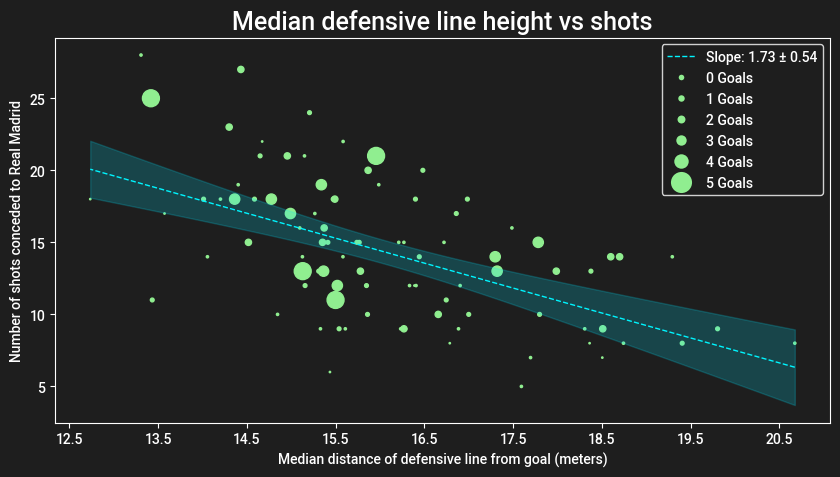

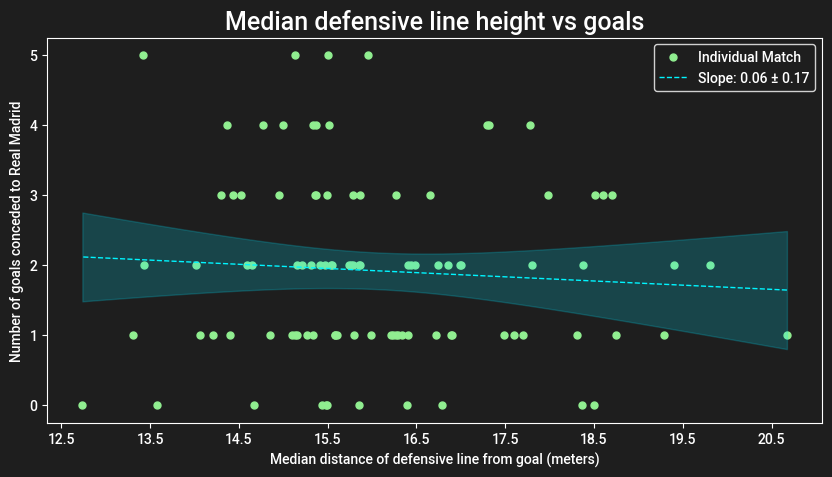

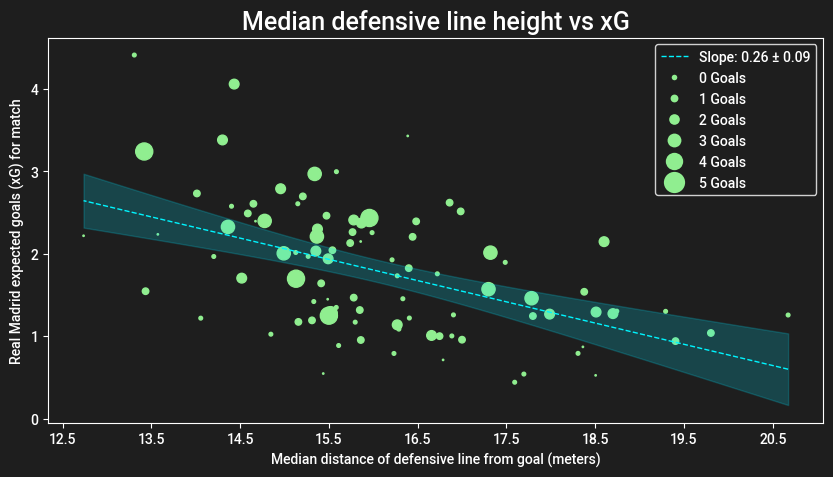

In [87]:
plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['rma_shots'].to_numpy(),
  title='Median defensive line height vs shots',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Number of shots conceded to Real Madrid',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
)

plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['rma_goals'].to_numpy(),
  title='Median defensive line height vs goals',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Number of goals conceded to Real Madrid',
)

plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['rma_xG'].to_numpy(),
  title='Median defensive line height vs xG',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Real Madrid expected goals (xG) for match',
  point_sizes=((data_df['rma_goals'] + 1).pow(2.8)).to_list(),
)

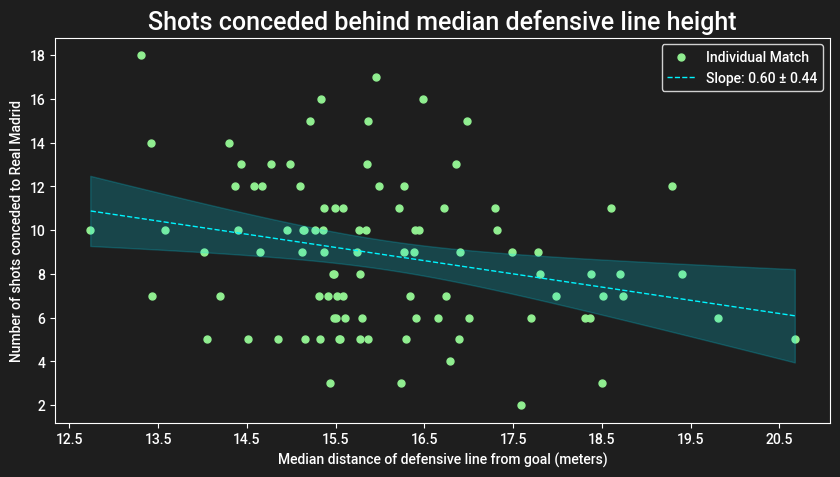

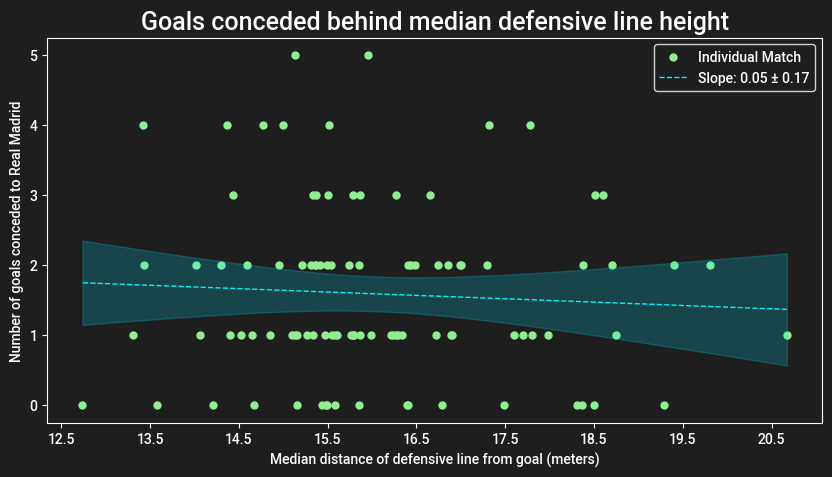

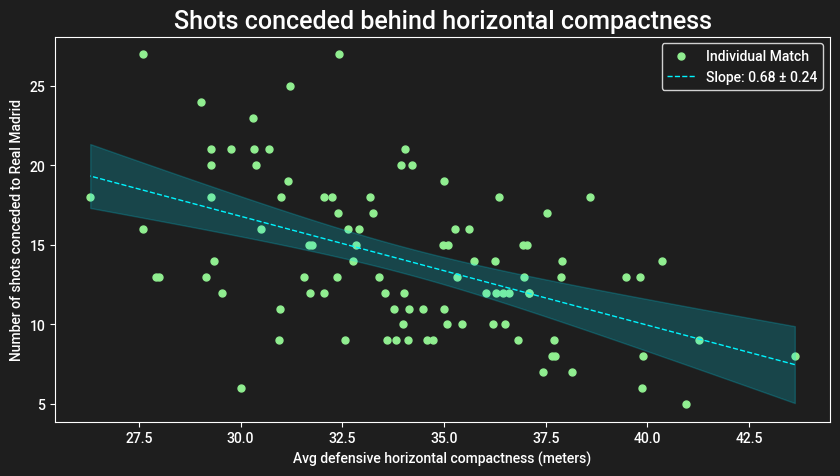

In [88]:
plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['num_shots_behind_def_line'].to_numpy(),
  title='Shots conceded behind median defensive line height',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Number of shots conceded to Real Madrid',
  # point_sizes=((data_df['rma_goals'] + 1).pow(2.8)).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['num_goals_behind_def_line'].to_numpy(),
  title='Goals conceded behind median defensive line height',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Number of goals conceded to Real Madrid',
  # point_sizes=((data_df['rma_goals'] + 1).pow(2.8)).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

plot_line_height(
  data_df['min_horiz_avg'].to_numpy(),
  data_df['num_shots_behind_horiz'].to_numpy(),
  title='Shots conceded behind horizontal compactness',
  x_label='Avg defensive horizontal compactness (meters)',
  y_label='Number of shots conceded to Real Madrid',
  # point_sizes=((data_df['rma_goals'] + 1).pow(2.8)).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

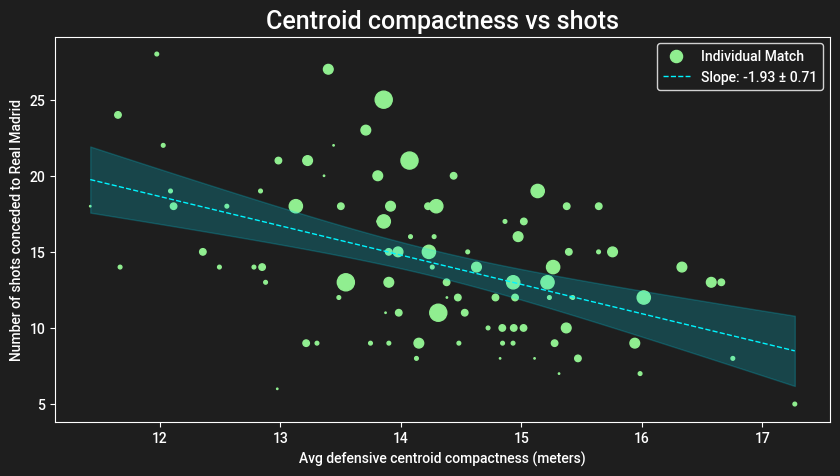

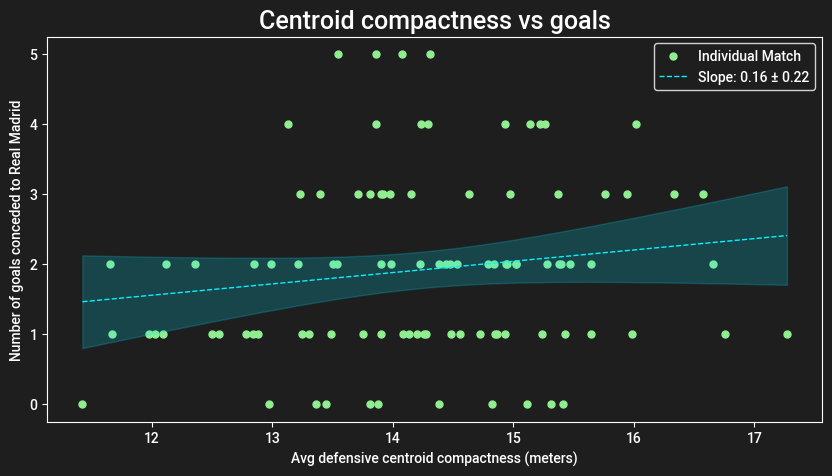

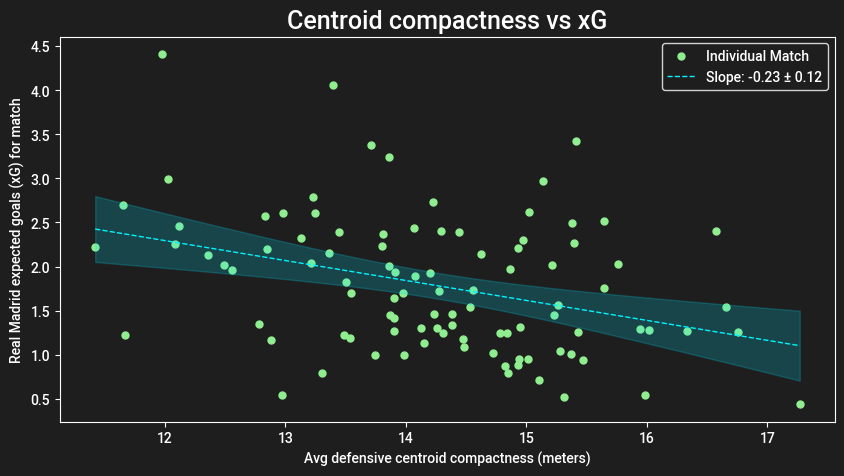

In [91]:
draw_plot(
  data_df['def_compact'].to_numpy(),
  data_df['rma_shots'].to_numpy(),
  title='Centroid compactness vs shots',
  x_label='Avg defensive centroid compactness (meters)',
  y_label='Number of shots conceded to Real Madrid',
  point_sizes=((data_df['rma_goals'] + 1).pow(2.8)).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

draw_plot(
  data_df['def_compact'].to_numpy(),
  data_df['rma_goals'].to_numpy(),
  title='Centroid compactness vs goals',
  x_label='Avg defensive centroid compactness (meters)',
  y_label='Number of goals conceded to Real Madrid',
)

draw_plot(
  data_df['def_compact'].to_numpy(),
  data_df['rma_xG'].to_numpy(),
  title='Centroid compactness vs xG',
  x_label='Avg defensive centroid compactness (meters)',
  y_label='Real Madrid expected goals (xG) for match',
)


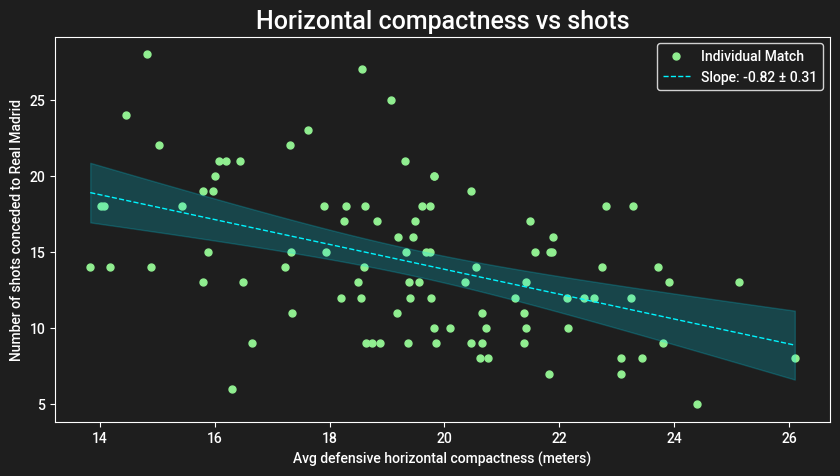

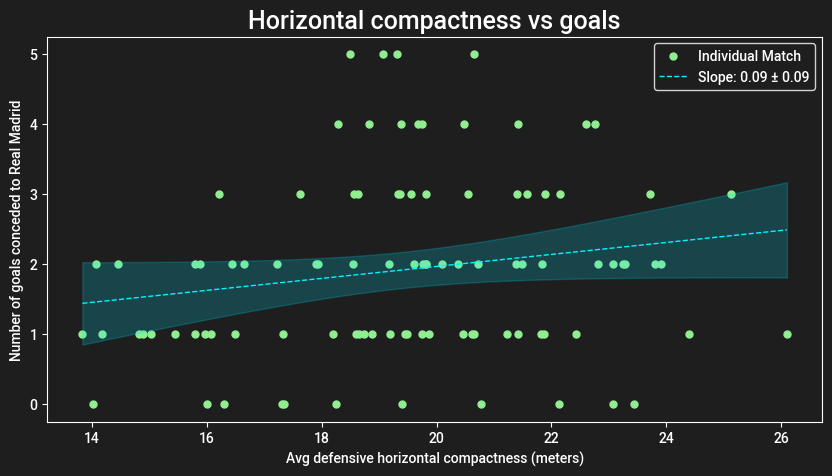

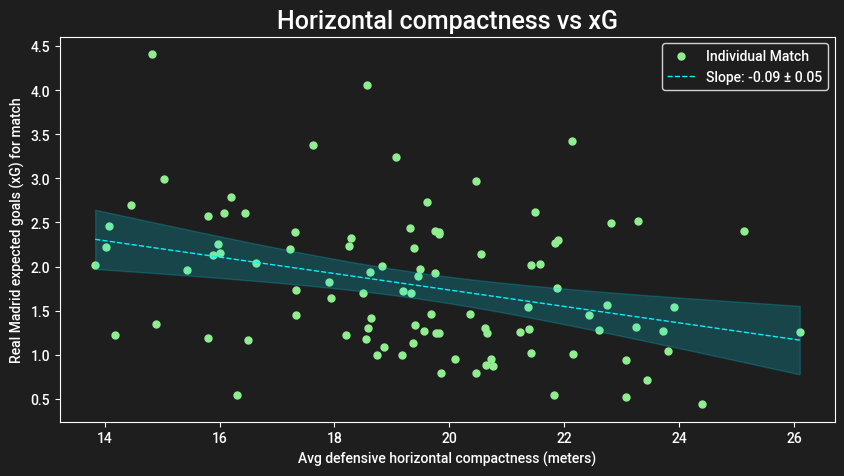

In [92]:
draw_plot(
  data_df['horiz_compact'].to_numpy(),
  data_df['rma_shots'].to_numpy(),
  title='Horizontal compactness vs shots',
  x_label='Avg defensive horizontal compactness (meters)',
  y_label='Number of shots conceded to Real Madrid',
)

draw_plot(
  data_df['horiz_compact'].to_numpy(),
  data_df['rma_goals'].to_numpy(),
  title='Horizontal compactness vs goals',
  x_label='Avg defensive horizontal compactness (meters)',
  y_label='Number of goals conceded to Real Madrid',
)

draw_plot(
  data_df['horiz_compact'].to_numpy(),
  data_df['rma_xG'].to_numpy(),
  title='Horizontal compactness vs xG',
  x_label='Avg defensive horizontal compactness (meters)',
  y_label='Real Madrid expected goals (xG) for match',
)

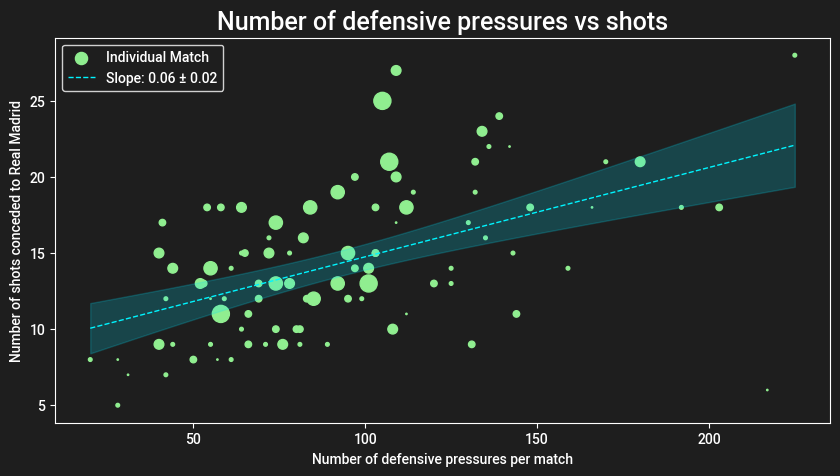

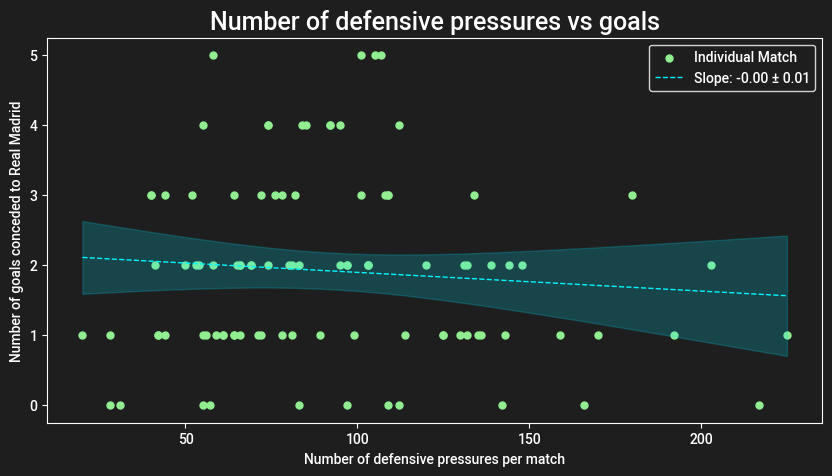

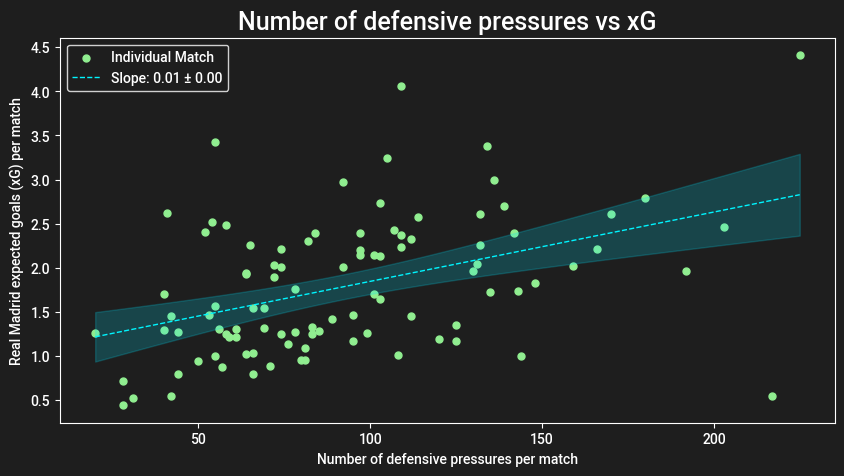

In [97]:
draw_plot(
  data_df['num_pressures'].to_numpy(),
  data_df['rma_shots'].to_numpy(),
  title='Number of defensive pressures vs shots',
  x_label='Number of defensive pressures per match',
  y_label='Number of shots conceded to Real Madrid',
  # match_ids=data_df['match_id'].to_list(),
  point_sizes=((data_df['rma_goals'] + 1).pow(2.8)).to_list(),
)

draw_plot(
  data_df['num_pressures'].to_numpy(),
  data_df['rma_goals'].to_numpy(),
  title='Number of defensive pressures vs goals',
  x_label='Number of defensive pressures per match',
  y_label='Number of goals conceded to Real Madrid',
)

draw_plot(
  data_df['num_pressures'].to_numpy(),
  data_df['rma_xG'].to_numpy(),
  title='Number of defensive pressures vs xG',
  x_label='Number of defensive pressures per match',
  y_label='Real Madrid expected goals (xG) per match',
)

In [20]:
pl.read_json('Skillcorner data/RealMadrid/meta/1816744.json')

id,home_team_score,away_team_score,date_time,stadium,home_team,home_team_kit,away_team,away_team_kit,home_team_coach,away_team_coach,competition_edition,competition_round,referees,players,status,home_team_side,ball,pitch_length,pitch_width
i64,i64,i64,str,struct[4],struct[4],struct[6],struct[4],struct[6],struct[3],struct[3],struct[4],struct[4],list[null],list[struct[18]],str,list[str],struct[1],i64,i64
1816744,0,4,"""2024-10-26T19:00:00Z""","{4,""Santiago Bernabeu"",""Madrid"",80000}","{262,""Real Madrid CF"",""Real Madrid"",""REA""}","{20,262,{3,2016,2017,""2016/2017""},""home"",""#ffffff"",""#000000""}","{264,""FC Barcelona"",""FC Barcelona"",""BAR""}","{132,264,{4,2017,2018,""2017/2018""},""home"",""#182fa8"",""#ffffff""}","{705,"""",""Zinedine Zidane""}","{88,""Ronald"",""Koeman""}","{900,{4,""ESP"",""LaLiga"",""male"",""adult""},{95,2024,2025,""2024/2025""},""ESP - LaLiga - 2024/2025""}","{93,""Round 11"",11,false}",[],"[{{20,""Full Back"",""Right Back"",""RB""},""00:00:00"",null,17,0,0,false,0,0,223,262,6373,""Lucas"",""Vázquez Iglesias"",""Lucas Vázquez"",""1991-07-01"",6383,""male""}, {{21,""Midfield"",""Left Defensive Midfield"",""LDM""},""00:00:00"",""01:04:25"",17,1,0,false,0,0,429195,264,69884,""Marc"",""Casadó Torras"",""Marc Casadó"",""2003-09-14"",71010,""male""}, … {{0,""Other"",""Goalkeeper"",""GK""},""00:00:00"",null,13,0,0,false,0,0,6668,262,12248,""Andriy"",""Lunin"",""A. Lunin"",""1999-02-11"",12392,""male""}]","""closed""","[""right_to_left"", ""left_to_right""]",{55},105,68


In [21]:
data_df.filter(
  pl.col('rma_goals') == 5
)

match_id,rma_shots,rma_goals,def_median,mid_median,att_median,def_compact,horiz_compact,vert_compact,num_pressures,home_team,away_team,rma_opponent,rma_xG,oppo_xG
i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,str,str,str,f64,f64
1534700,21,5,36.543333,18.086667,-1.606667,14.072354,19.317346,25.691649,107,"""Real Madrid""","""Alavés""","""Alavés""",2.433361,1.462337


In [22]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=200):
  print(data_df.filter(pl.col('rma_goals') == 0))

shape: (1, 15)
┌──────────┬───────────┬───────────┬────────────┬────────────┬────────────┬─────────────┬───────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────┬─────────┐
│ match_id ┆ rma_shots ┆ rma_goals ┆ def_median ┆ mid_median ┆ att_median ┆ def_compact ┆ horiz_compact ┆ vert_compact ┆ num_pressure ┆ home_team   ┆ away_team    ┆ rma_opponent ┆ rma_xG   ┆ oppo_xG │
│ ---      ┆ ---       ┆ ---       ┆ ---        ┆ ---        ┆ ---        ┆ ---         ┆ ---           ┆ ---          ┆ s            ┆ ---         ┆ ---          ┆ ---          ┆ ---      ┆ ---     │
│ i64      ┆ i64       ┆ i64       ┆ f64        ┆ f64        ┆ f64        ┆ f64         ┆ f64           ┆ f64          ┆ ---          ┆ str         ┆ str          ┆ str          ┆ f64      ┆ f64     │
│          ┆           ┆           ┆            ┆            ┆            ┆             ┆               ┆              ┆ i64          ┆             ┆              ┆              ┆  

In [23]:
meta_example_df = pl.read_json('Skillcorner data/RealMadrid/meta/1534700.json')
dynam_example_df = pl.read_parquet('Skillcorner data/RealMadrid/dynamic/1534700.parquet')
meta_example_df

id,home_team_score,away_team_score,date_time,stadium,home_team,home_team_kit,away_team,away_team_kit,home_team_coach,away_team_coach,competition_edition,competition_round,referees,players,status,home_team_side,ball,pitch_length,pitch_width
i64,i64,i64,str,struct[4],struct[4],struct[6],struct[4],struct[6],struct[3],struct[3],struct[4],struct[4],list[null],list[struct[18]],str,list[str],struct[1],i64,i64
1534700,5,0,"""2024-05-14T19:30:00Z""","{4,""Santiago Bernabeu"",""Madrid"",80000}","{262,""Real Madrid CF"",""Real Madrid"",""REA""}","{20,262,{3,2016,2017,""2016/2017""},""home"",""#ffffff"",""#000000""}","{313,""Deportivo Alavés"",""Alavés"",""ALA""}","{126,313,{4,2017,2018,""2017/2018""},""home"",""#0000ff"",""#ffffff""}","{705,"""",""Zinedine Zidane""}","{197,""Javier"",""Calleja""}","{546,{4,""ESP"",""LaLiga"",""male"",""adult""},{28,2023,2024,""2023/2024""},""ESP - LaLiga - 2023/2024""}","{118,""Round 36"",36,false}",[],"[{{11,""Midfield"",""Attacking Midfield"",""AM""},""00:00:00"",null,5,0,0,false,1,0,1062966,262,24583,""Jude"",""Bellingham"",""J. Bellingham"",""2003-06-29"",25615,""male""}, {{21,""Midfield"",""Left Defensive Midfield"",""LDM""},""00:00:00"",""01:01:29"",6,0,0,false,0,0,1083340,313,13916,""Ander"",""Guevara Lajo"",""Ander Guevara"",""1997-07-07"",14113,""male""}, … {{20,""Full Back"",""Right Back"",""RB""},""00:00:00"",null,2,0,0,false,0,0,961,262,2189,""Daniel"",""Carvajal Ramos"",""Dani Carvajal"",""1992-01-11"",2199,""male""}]","""closed""","[""left_to_right"", ""right_to_left""]",{55},105,68


In [24]:
track_players_df.filter(
  pl.col('frame').is_in(att_third_frames),
  pl.col('player_id').is_in(oppo_non_gk_player_ids)
)

frame,timestamp,period,x,y,player_id,is_detected
i64,str,i64,f64,f64,i64,bool
81,"""00:00:07.10""",1,21.76,-6.11,673618,true
81,"""00:00:07.10""",1,24.32,-20.95,4465,true
81,"""00:00:07.10""",1,17.12,10.84,11630,true
81,"""00:00:07.10""",1,23.4,-28.1,53347,true
81,"""00:00:07.10""",1,12.62,-3.56,69884,true
…,…,…,…,…,…,…
55574,"""01:30:26.40""",2,35.48,-1.19,12378,false
55574,"""01:30:26.40""",2,7.6,-14.05,12426,false
55574,"""01:30:26.40""",2,14.56,20.86,639784,false


In [25]:
goal_coords_np = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('game_interruption_after') == 'goal_for'
  )['x_end', 'y_end'].to_numpy()

shot_coords_np = dynam_df.filter(
  pl.col('team_id') == REAL_MADRID_TEAM_ID,
  pl.col('end_type') == 'shot',
)['x_end', 'y_end'].to_numpy()

pressures_flip = pressures_on_rma.with_columns(
  pl.when(pl.col('period') == period_to_swap)
  .then(pl.col('x_start', 'x_end', 'y_start', 'y_end') * -1)
  .otherwise(pl.col('x_start', 'x_end', 'y_start', 'y_end'))
)

In [26]:
pressures_flip = pressures_on_rma.with_columns(
  pl.when(pl.col('period') == period_to_swap)
  .then(pl.col('x_start', 'x_end', 'y_start', 'y_end') * -1)
  .otherwise(pl.col('x_start', 'x_end', 'y_start', 'y_end'))
)

In [27]:
heatmap_data[1534700]['def_coords']

frame,timestamp,period,x,y,player_id,is_detected
i64,str,i64,f64,f64,i64,bool
124,"""00:00:11.40""",1,22.16,16.46,37823,false
124,"""00:00:11.40""",1,25.59,-7.88,93039,false
124,"""00:00:11.40""",1,-3.78,26.33,13911,false
124,"""00:00:11.40""",1,3.58,-17.18,9335,false
124,"""00:00:11.40""",1,2.87,-3.24,13916,false
…,…,…,…,…,…,…
56486,"""01:30:55.60""",2,30.29,-0.62,37337,true
56486,"""01:30:55.60""",2,4.85,18.9,62170,false
56486,"""01:30:55.60""",2,-9.62,-7.46,24051,false


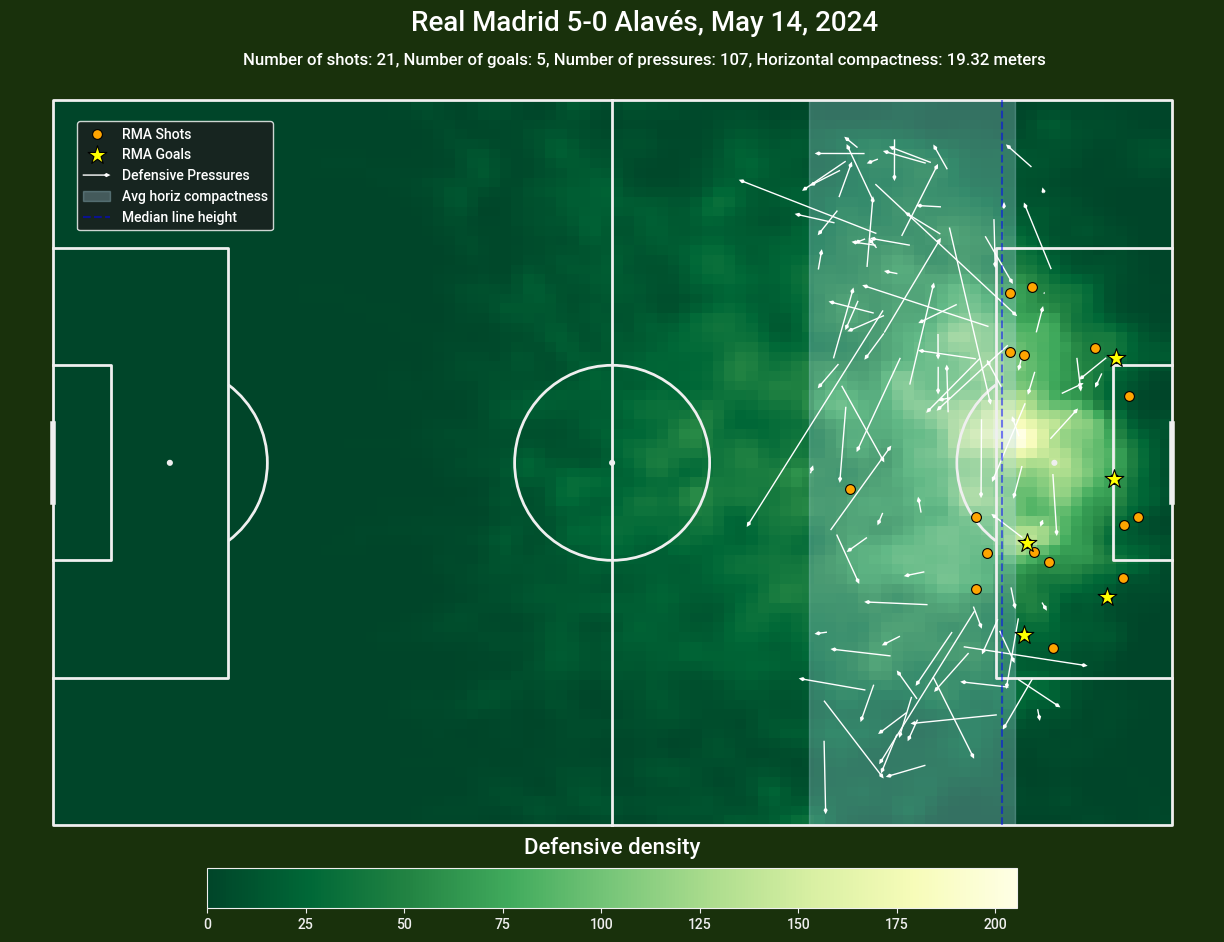

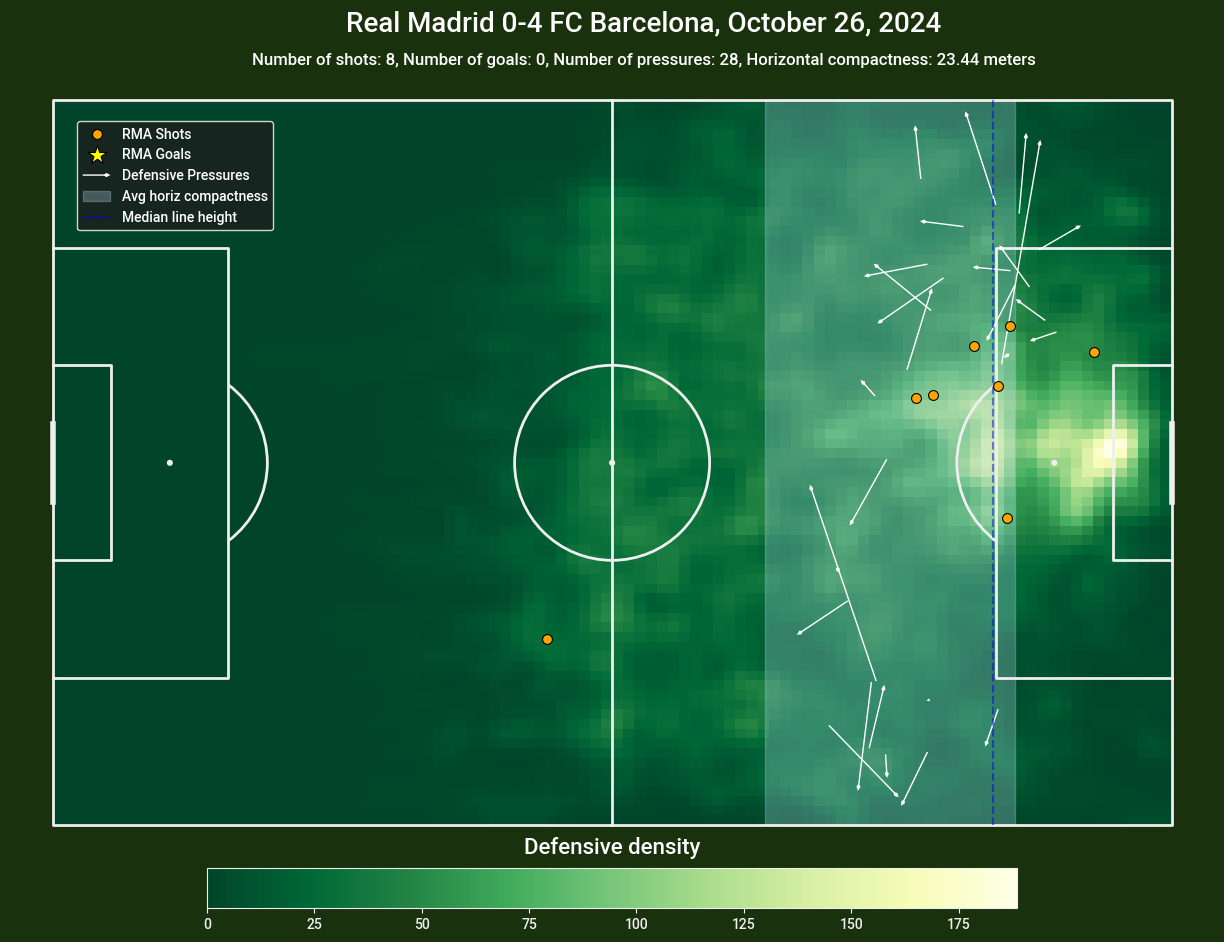

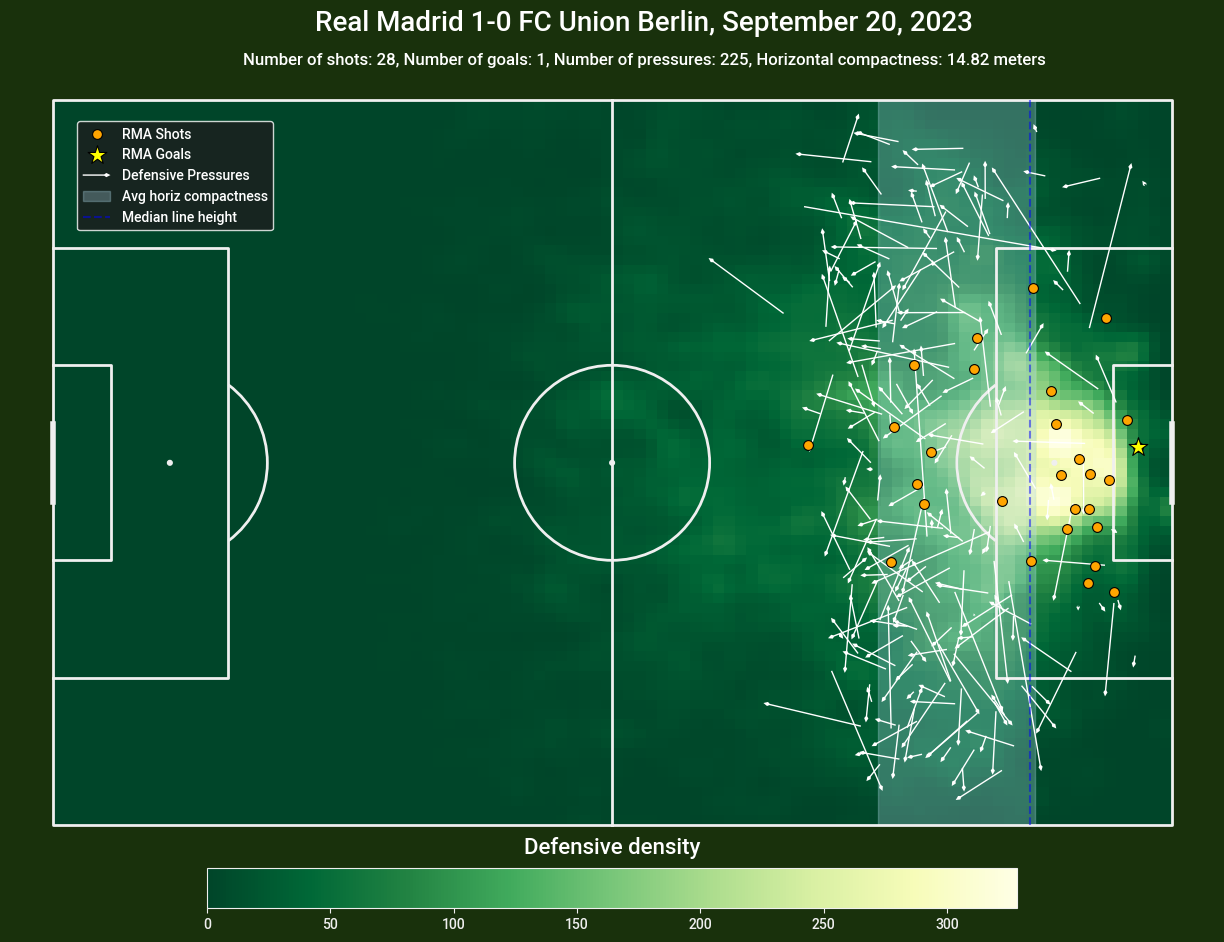

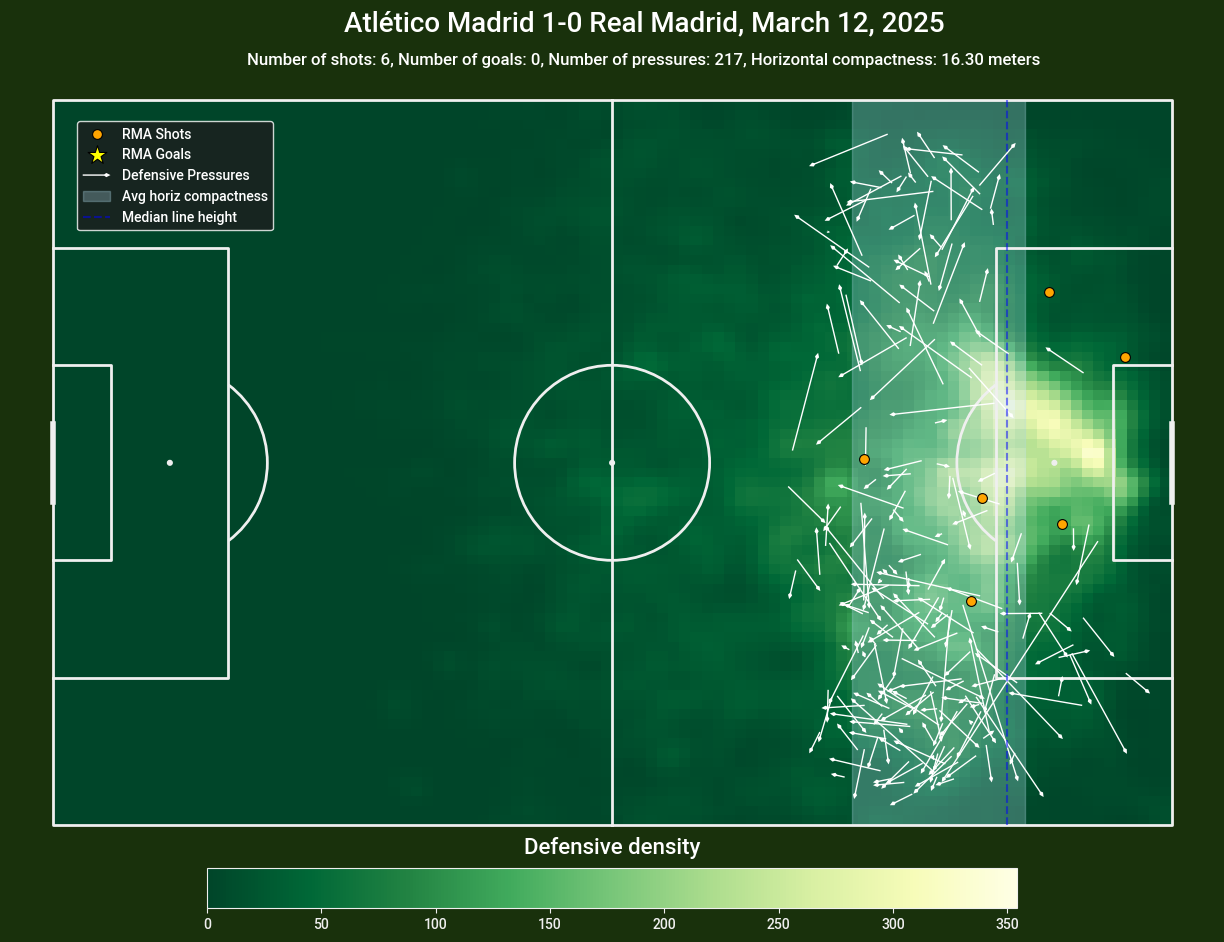

In [98]:
for match_id, data in heatmap_data.items():
  # pitch = Pitch(pitch_type='skillcorner', pitch_width=68, pitch_length=105, line_zorder=2,
  #               pitch_color='#22312b', line_color='#efefef')
  pitch = Pitch(pitch_type='skillcorner', pitch_width=68, pitch_length=105, line_zorder=2,
                pitch_color='#19310c', line_color='#efefef')
  fig, ax = pitch.draw(figsize=(6.6*2.5, 4.125*2.5))
  # fig.set_facecolor('#22312b')
  fig.set_facecolor('#19310c')

  def_coords_np = data['def_coords'].select('x', 'y').to_numpy()
  bin_statistic = pitch.bin_statistic(def_coords_np[:, 0], def_coords_np[:, 1], statistic='count', bins=(100, 75))
  bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
  pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='YlGn_r')
  # Add the colorbar and format off-white
  cbar = fig.colorbar(pcm, ax=ax, shrink=0.5, orientation='horizontal', location='bottom', pad=0)
  # cbar.ax.yaxis.set_ticks_position('left')
  cbar.outline.set_edgecolor('#efefef')
  cbar.ax.xaxis.set_tick_params(color='#efefef')
  cbar.ax.yaxis.set_tick_params(color='#efefef')
  ticks = plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), color='#efefef')
  ticks = plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#efefef')
  cbar.set_label('Defensive density', color=TEXT_COLOR, size=16)
  cbar.ax.xaxis.set_label_position('top')
  cbar.ax.xaxis.labelpad = 10

  # Defensive coordinate density heatmap
  pitch.scatter(data['rma_shots'][:, 0], data['rma_shots'][:, 1], ax=ax, s=50, c='orange', edgecolors='black', linewidth=0.8, marker='o', label='RMA Shots', zorder=3)
  pitch.scatter(data['rma_goals'][:, 0], data['rma_goals'][:, 1], ax=ax, s=200, c='yellow', edgecolors='black', linewidth=0.8, marker='*', label='RMA Goals', zorder=4)
  pitch.arrows(
    data['pressures']['x_start'] * -1,
    data['pressures']['y_start'] * -1,
    data['pressures']['x_end'] * -1,
    data['pressures']['y_end'] * -1,
    ax=ax, color='white', width=1, headwidth=3, headlength=3, label='Defensive Pressures', zorder=2)
  # ax.axvspan(xmin=35, xmax=45, color='lightblue', alpha=0.3) #, zorder=1)
  ax.fill_betweenx(
    y=[-34, 34],
    x1=data['horiz_compact']['max_horiz'].mean(),
    x2=data['horiz_compact']['min_horiz'].mean(),
    color='lightblue',
    alpha=0.3,
    zorder=1,
    label='Avg horiz compactness')
  # Line height
  ax.plot([data['line_height'], data['line_height']], [-34, 34], color='blue', alpha=0.5, linestyle='--', label='Median line height')

  # Title
  ax.text(
    3, 40,
    f'{data['home_team']} {data['home_team_score']}-{data['away_team_score']} {data['away_team']}, {data['date']}',
    ha='center',
    va='bottom',
    fontsize=20,
    color=TEXT_COLOR,
  )
  # Subtitle
  ax.text(
    3, 38.5,
    f'Number of shots: {len(data["rma_shots"])}, Number of goals: {len(data["rma_goals"])}, Number of pressures: {len(data["pressures"])}, Horizontal compactness: {data["horiz_compact"]["max_horiz"].mean() - data["horiz_compact"]["min_horiz"].mean():.2f} meters',
    ha='center',
    va='top',
    fontsize='12',
    color=TEXT_COLOR,
  )
  plt.legend(loc='upper left', bbox_to_anchor=(0.05, 0.93), facecolor=BG_COLOR, edgecolor=TEXT_COLOR, labelcolor=TEXT_COLOR)


In [ ]:
import shap
import xgboost as xgb

targets = data_df['rma_shots', 'rma_goals'].to_numpy()
feature_cols = ['def_median', 'def_compact', 'horiz_compact', 'num_pressures']
features = data_df[feature_cols].to_numpy()

model = xgb.XGBRegressor()
model.fit(features, targets[:, 0])

explainer = shap.Explainer(model, features)
targets = data_df['rma_shots', 'rma_goals'].to_numpy()
feature_cols = ['def_median', 'def_compact', 'horiz_compact', 'num_pressures']
features = data_df[feature_cols].to_numpy()

model = xgb.XGBRegressor()
model.fit(features, targets[:, 0])

explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
shap_values = explainer(features)

shap.plots.bar(shap_values)

shap.plots.bar(features)

NotImplementedError: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.